SECTION 01 : TRAINING PHASE 

STEP 01 - IMPORTING TRAINING DATASET


In [2]:
import pandas as pd

In [3]:
df = pd.read_csv("C:\\Users\\vic\\Desktop\\shhhh\\dataanalyticsproject\\customer_churn_dataset_training_master.csv")
print(df.head())

   CustomerID   Age  Gender  Tenure  Usage Frequency  Support Calls  \
0         2.0  30.0  Female    39.0             14.0            5.0   
1         3.0  65.0  Female    49.0              1.0           10.0   
2         4.0  55.0  Female    14.0              4.0            6.0   
3         5.0  58.0    Male    38.0             21.0            7.0   
4         6.0  23.0    Male    32.0             20.0            5.0   

   Payment Delay Subscription Type Contract Length  Total Spend  \
0           18.0          Standard          Annual        932.0   
1            8.0             Basic         Monthly        557.0   
2           18.0             Basic       Quarterly        185.0   
3            7.0          Standard         Monthly        396.0   
4            8.0             Basic         Monthly        617.0   

   Last Interaction  Churn  
0              17.0    1.0  
1               6.0    1.0  
2               3.0    1.0  
3              29.0    1.0  
4              20.0    1.

STEP 02 - ANALYZING TRAINING DATASET

In [4]:
df.shape

(440833, 12)

In [5]:
df.columns

Index(['CustomerID', 'Age', 'Gender', 'Tenure', 'Usage Frequency',
       'Support Calls', 'Payment Delay', 'Subscription Type',
       'Contract Length', 'Total Spend', 'Last Interaction', 'Churn'],
      dtype='str')

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 440833 entries, 0 to 440832
Data columns (total 12 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   CustomerID         440832 non-null  float64
 1   Age                440832 non-null  float64
 2   Gender             440832 non-null  str    
 3   Tenure             440832 non-null  float64
 4   Usage Frequency    440832 non-null  float64
 5   Support Calls      440832 non-null  float64
 6   Payment Delay      440832 non-null  float64
 7   Subscription Type  440832 non-null  str    
 8   Contract Length    440832 non-null  str    
 9   Total Spend        440832 non-null  float64
 10  Last Interaction   440832 non-null  float64
 11  Churn              440832 non-null  float64
dtypes: float64(9), str(3)
memory usage: 40.4 MB


In [7]:
df.describe()

,CustomerID,Age,Tenure,Usage Frequency,Support Calls,Payment Delay,Total Spend,Last Interaction,Churn
count,440832.000000,440832.000000,440832.000000,440832.000000,440832.000000,440832.000000,440832.000000,440832.000000,440832.000000
mean,225398.667955,39.373153,31.256336,15.807494,3.604437,12.965722,631.616223,14.480868,0.567107
std,129531.918550,12.442369,17.255727,8.586242,3.070218,8.258063,240.803001,8.596208,0.495477
min,2.000000,18.000000,1.000000,1.000000,0.000000,0.000000,100.000000,1.000000,0.000000
25%,113621.750000,29.000000,16.000000,9.000000,1.000000,6.000000,480.000000,7.000000,0.000000
50%,226125.500000,39.000000,32.000000,16.000000,3.000000,12.000000,661.000000,14.000000,1.000000
75%,337739.250000,48.000000,46.000000,23.000000,6.000000,19.000000,830.000000,22.000000,1.000000
max,449999.000000,65.000000,60.000000,30.000000,10.000000,30.000000,1000.000000,30.000000,1.000000


STEP 03 - UNDERSTANDING DATASET CHRUN

In [8]:
df['Churn'].value_counts()

Churn
1.0    249999
0.0    190833
Name: count, dtype: int64

In [9]:
df.groupby('Churn').mean(numeric_only=True)

,CustomerID,Age,Tenure,Usage Frequency,Support Calls,Payment Delay,Total Spend,Last Interaction
Churn,,,,,,,,
0.0,349841.428144,36.262973,32.281754,16.260552,1.586418,10.015500,749.953111,13.008804
1.0,130407.146969,41.747263,30.473598,15.461658,5.144861,15.217729,541.285528,15.604546


STEP 04 - VISUALIZATION OF TRAINING DATASETS


In [10]:
pip install seaborn matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style("whitegrid")
sns.set_context("talk")

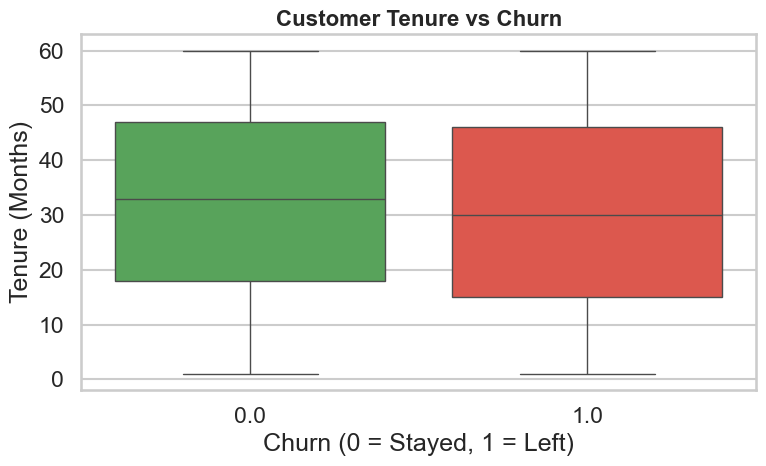

In [12]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='Churn',
    y='Tenure',
    hue='Churn',
    data=df,
    palette={0: "#4CAF50", 1: "#F44336"},
    legend=False
)

plt.title("Customer Tenure vs Churn", fontsize=16, fontweight='bold')
plt.xlabel("Churn (0 = Stayed, 1 = Left)")
plt.ylabel("Tenure (Months)")

plt.tight_layout()
plt.show()

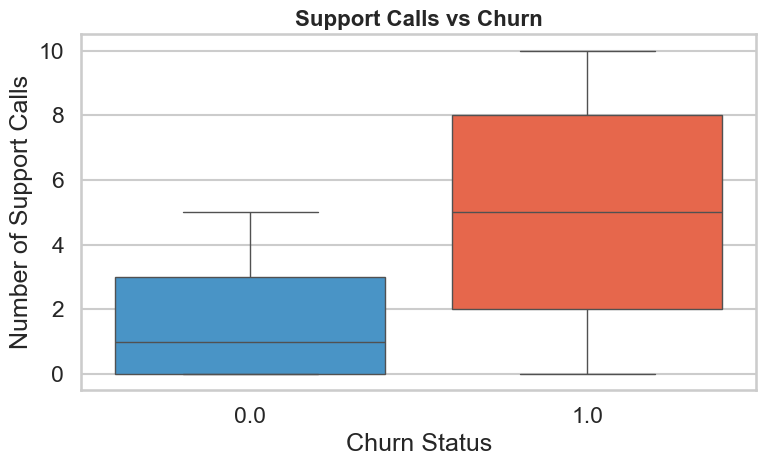

In [13]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='Churn',
    y='Support Calls',
    hue='Churn',
    data=df,
    palette={0: "#3498DB", 1: "#FF5733"},
    legend=False
)

plt.title("Support Calls vs Churn", fontsize=16, fontweight='bold')
plt.xlabel("Churn Status")
plt.ylabel("Number of Support Calls")

plt.tight_layout()
plt.show()

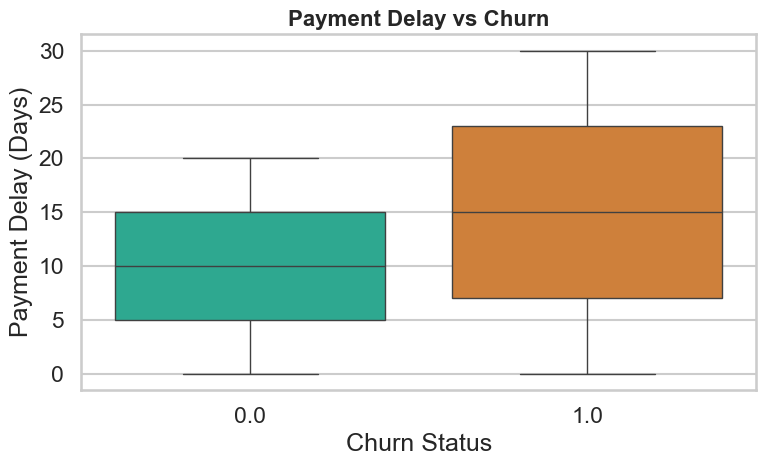

In [14]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='Churn',
    y='Payment Delay',
    hue='Churn',
    data=df,
    palette={0: "#1ABC9C", 1: "#E67E22"},
    legend=False
)

plt.title("Payment Delay vs Churn", fontsize=16, fontweight='bold')
plt.xlabel("Churn Status")
plt.ylabel("Payment Delay (Days)")

plt.tight_layout()
plt.show()


CATEGORICAL ANALYSIS

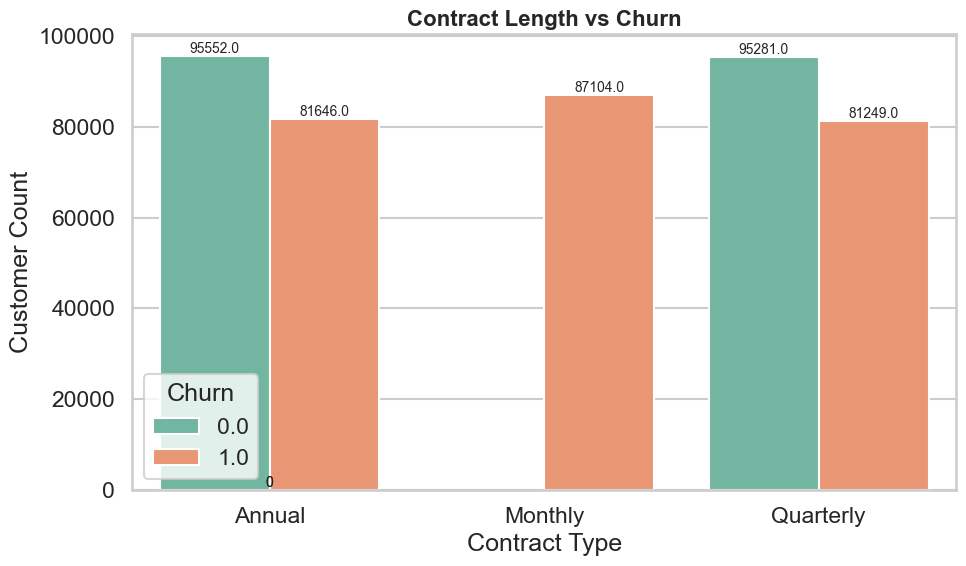

In [15]:
plt.figure(figsize=(10,6))

ax = sns.countplot(
    x='Contract Length',
    hue='Churn',
    data=df,
    palette='Set2'
)

plt.title("Contract Length vs Churn", fontsize=16, fontweight='bold')
plt.xlabel("Contract Type")
plt.ylabel("Customer Count")

# Add labels
for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{height}', 
                (p.get_x() + p.get_width()/2, height),
                ha='center', va='bottom', fontsize=10)

plt.legend(title="Churn")
plt.tight_layout()
plt.show()

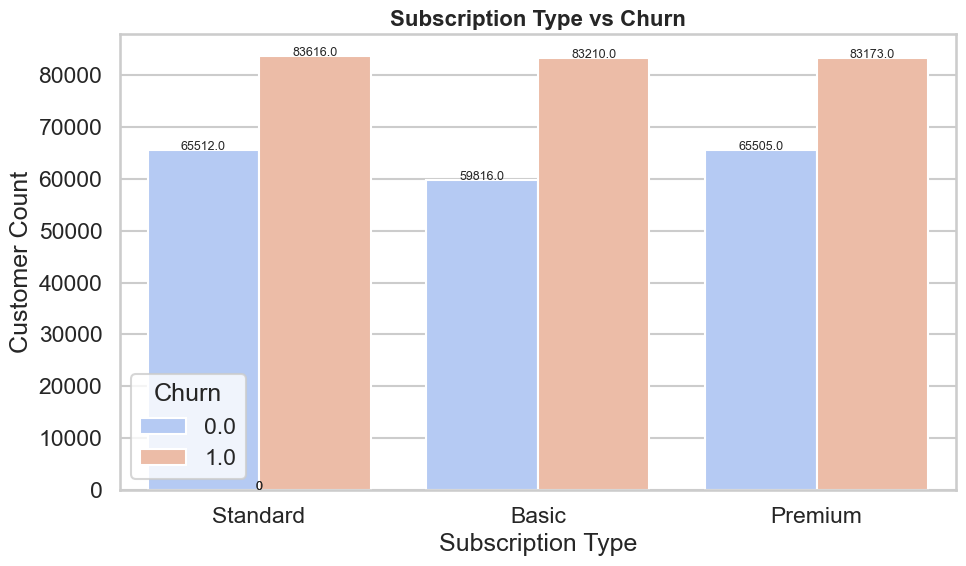

In [16]:
plt.figure(figsize=(10,6))

ax = sns.countplot(
    x='Subscription Type',
    hue='Churn',
    data=df,
    palette='coolwarm'
)

plt.title("Subscription Type vs Churn", fontsize=16, fontweight='bold')
plt.xlabel("Subscription Type")
plt.ylabel("Customer Count")

for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{height}', 
                (p.get_x() + p.get_width()/2, height),
                ha='center', fontsize=9)

plt.legend(title="Churn")
plt.tight_layout()
plt.show()

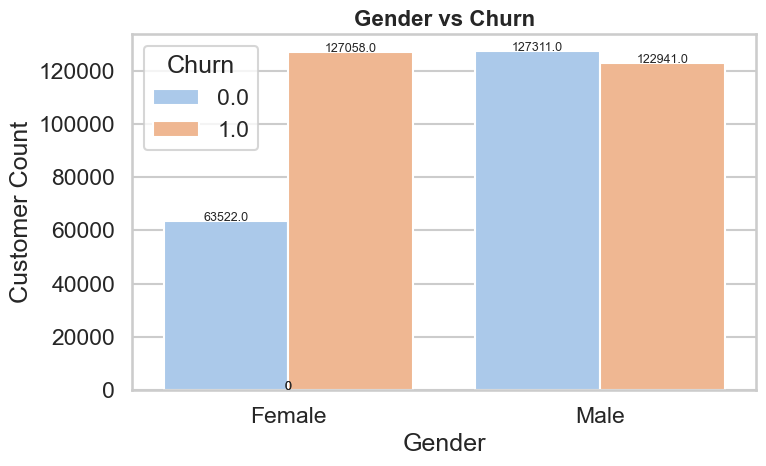

In [17]:
plt.figure(figsize=(8,5))

ax = sns.countplot(
    x='Gender',
    hue='Churn',
    data=df,
    palette='pastel'
)

plt.title("Gender vs Churn", fontsize=16, fontweight='bold')
plt.xlabel("Gender")
plt.ylabel("Customer Count")

for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{height}', 
                (p.get_x() + p.get_width()/2, height),
                ha='center', fontsize=9)

plt.legend(title="Churn")
plt.tight_layout()
plt.show()

STEP 05 - CATEGORICAL TO NUMERIC

In [18]:
df_encoded = pd.get_dummies(df, drop_first=True)

In [19]:
df_encoded.head()

,CustomerID,Age,Tenure,Usage Frequency,Support Calls,Payment Delay,Total Spend,Last Interaction,Churn,Gender_Male,Subscription Type_Premium,Subscription Type_Standard,Contract Length_Monthly,Contract Length_Quarterly
0,2.0,30.0,39.0,14.0,5.0,18.0,932.0,17.0,1.0,False,False,True,False,False
1,3.0,65.0,49.0,1.0,10.0,8.0,557.0,6.0,1.0,False,False,False,True,False
2,4.0,55.0,14.0,4.0,6.0,18.0,185.0,3.0,1.0,False,False,False,False,True
3,5.0,58.0,38.0,21.0,7.0,7.0,396.0,29.0,1.0,True,False,True,True,False
4,6.0,23.0,32.0,20.0,5.0,8.0,617.0,20.0,1.0,True,False,False,True,False


STEP 06 - PREPARE DATA FOR MODEL

In [20]:
X = df_encoded.drop('Churn', axis=1)
y = df_encoded['Churn']

In [21]:
from sklearn.model_selection import train_test_split

In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

STEP 07 - BUILD FIRST MODEL

Logistic Regression 

In [23]:
df = df.dropna()

In [24]:
print(df.isnull().sum().sum()) 

0


In [25]:
df_encoded = pd.get_dummies(df, drop_first=True)

# Double-check again
print(df_encoded.isnull().sum().sum()) 

0


In [26]:
X = df_encoded.drop(['Churn', 'CustomerID'], axis=1)

In [27]:
from sklearn.model_selection import train_test_split

X = df_encoded.drop('Churn', axis=1)
y = df_encoded['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [28]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [29]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

c:\Users\vic\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

STEP 08 - EVALUATE YOUR MODEL

In [30]:
y_pred = model.predict(X_test_scaled)

c:\Users\vic\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


In [31]:
from sklearn.metrics import classification_report, confusion_matrix

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[29080  8983]
 [13349 36755]]
              precision    recall  f1-score   support

         0.0       0.69      0.76      0.72     38063
         1.0       0.80      0.73      0.77     50104

    accuracy                           0.75     88167
   macro avg       0.74      0.75      0.74     88167
weighted avg       0.75      0.75      0.75     88167



Why is recall more important than accuracy in this project?

1. Recall is more important than accuracy in churn prediction because the primary goal is to identify customers who are likely to leave.
2. Missing a churn customer (false negative) results in a direct loss for the company, as no retention strategy can be applied.
3. A high recall ensures that most of the potential churn customers are correctly identified, allowing the company to take preventive actions.

STEP 09 - FEATURE IMPORTANCE 



In [32]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_[0]
})

feature_importance = feature_importance.sort_values(by='Coefficient', ascending=False)

print(feature_importance.head(10))

                       Feature  Coefficient
11     Contract Length_Monthly     4.067088
4                Support Calls     0.775206
9    Subscription Type_Premium     0.538360
10  Subscription Type_Standard     0.531498
5                Payment Delay     0.153446
7             Last Interaction     0.090802
1                          Age     0.075430
3              Usage Frequency     0.036601
2                       Tenure     0.010093
0                   CustomerID    -0.000033


In [45]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         0.0       0.69      0.76      0.72     38063
         1.0       0.80      0.73      0.77     50104

    accuracy                           0.75     88167
   macro avg       0.74      0.75      0.74     88167
weighted avg       0.75      0.75      0.75     88167



STEP 10 - FINDINGS AND INSIGHTS

Key Findings

1. Customers with monthly contracts are significantly more likely to churn compared to long-term contract users.
2. A higher number of support calls is strongly associated with increased churn, indicating dissatisfaction among customers.
3. Customers with certain subscription types (Premium and Standard) show a higher likelihood of leaving, suggesting possible issues with service value.
4. Payment delays also contribute to churn, indicating financial or engagement-related concerns.

Why do you think monthly contract customers churn more than yearly ones?

1. Customers with monthly contracts are more likely to churn because they have greater flexibility to leave the service at any time.
2. In contrast, customers with long-term contracts (such as yearly plans) are more committed and less likely to switch services immediately.
3. Therefore, lower commitment levels in monthly plans lead to higher churn rates.

KEY INSIGHTS                    



1. Contract type is the strongest driver of churn - Customers on monthly plans are significantly more likely to leave due to lack of long-term commitment.
2. Customer dissatisfaction leads to churn - A higher number of support calls strongly indicates unresolved issues and poor service experience.
3. Payment behavior reflects engagement - Customers with delayed payments are more likely to churn, indicating weak engagement or dissatisfaction.
4. Subscription plans influence retention - Premium and Standard users show moderate churn risk, suggesting possible gaps in perceived value.
5. Behavioral factors matter more than demographics - Variables like age, tenure, and usage frequency have minimal impact compared to service-related factors.

STEP 11 - FINAL BUSINESS RECOMMENDATIONS

1. Recommended Strategies - 

    Promote long-term contracts

    Offer discounts or incentives for yearly or longer plans

    Reduce reliance on monthly subscriptions

2. Improve customer support quality -

    Reduce response time

    Resolve issues in fewer interactions

    Train support teams to handle complaints effectively

3. Monitor high-risk customers - 

    Identify customers with frequent support calls

    Target them with personalized offers or proactive support

4. Optimize payment experience -

    Send timely reminders for payments

    Offer flexible payment options

    Reduce billing-related friction

5. Enhance subscription value - 

    Re-evaluate Premium and Standard plans
    
    Add features or benefits to increase perceived value

STEP 12 - LIMITATION OR CONCLUSION

The model achieved a high accuracy of approximately 97%, which indicates strong predictive performance. However, this performance may be influenced by the nature of the dataset, which appears to have well-defined patterns and limited noise.


In real-world scenarios, customer behavior is often more complex and noisy, which may lead to lower model performance. Therefore, further validation on real-world data is recommended before deployment.

SECTION 02 : TESTING PHASE 

STEP 01 - LOADING TESTING DATASET

In [46]:
test_df = pd.read_csv("C:\\Users\\vic\\Desktop\\shhhh\\dataanalyticsproject\\customer_churn_dataset_testing_master.csv")

In [47]:
test_df = test_df.dropna()

test_encoded = pd.get_dummies(test_df, drop_first=True)

STEP 02 - ALIGNING COLUMNS 

In [48]:
test_encoded = test_encoded.reindex(columns=X.columns, fill_value=0)

STEP 03 - SCALING 

In [49]:
test_scaled = scaler.transform(test_encoded)

In [50]:
test_scaled = pd.DataFrame(
    scaler.transform(test_encoded),
    columns=test_encoded.columns
)

STEP 04 - PREDICTING

In [51]:
test_predictions = model.predict(test_scaled)

In [52]:
test_df['Predicted_Churn'] = test_predictions

test_df.to_csv("final_churn_predictions.csv", index=False)

SECTION 3 : VERIFYING 

STEp 01 - CHECKING PREDICTION SAMPLE

In [53]:
print(test_predictions[:10])

[1. 1. 1. 0. 1. 1. 1. 1. 1. 0.]


STEP 02 - CHECKING NEW COLUMN ADDED

In [54]:
print(test_df.head())

   CustomerID  Age  Gender  Tenure  Usage Frequency  Support Calls  \
0           1   22  Female      25               14              4   
1           2   41  Female      28               28              7   
2           3   47    Male      27               10              2   
3           4   35    Male       9               12              5   
4           5   53  Female      58               24              9   

   Payment Delay Subscription Type Contract Length  Total Spend  \
0             27             Basic         Monthly          598   
1             13          Standard         Monthly          584   
2             29           Premium          Annual          757   
3             17           Premium       Quarterly          232   
4              2          Standard          Annual          533   

   Last Interaction  Churn  Predicted_Churn  
0                 9      1              1.0  
1                20      0              1.0  
2                21      0            

VERIFYING CSV FILE SAVED 

In [55]:
import os

print(os.getcwd())

c:\Users\vic\Desktop\shhhh\dataanalyticsproject


RESULT

In [56]:
test_df[['CustomerID', 'Predicted_Churn']].head(20)

,CustomerID,Predicted_Churn
0,1,1.0
1,2,1.0
2,3,1.0
3,4,0.0
4,5,1.0
5,6,1.0
6,7,1.0
7,8,1.0
8,9,1.0
9,10,0.0


PROBABLITY SCORES

In [57]:
churn_probability = model.predict_proba(test_scaled)[:,1]

test_df['Churn_Probability'] = churn_probability